In [31]:
from pathlib import Path
import re
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import pytesseract
import easyocr

MRZ_ALLOWLIST = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789<"
COMMON_NATIONALITY_CODES = {
    "ARE","IND","USA","GBR","CAN","AUS","DEU","FRA","ITA","ESP","NLD","BEL",
    "CHE","AUT","SWE","NOR","DNK","FIN","IRL","PRT","NZL","SGP","MYS","IDN",
    "PHL","THA","VNM","JPN","KOR","CHN","HKG","MAC","TWN","PAK","BGD","LKA",
    "NPL","AFG","SAU","QAT","KWT","OMN","BHR","JOR","EGY","TUR","ZAF","BRA",
    "ARG","MEX","RUS","UKR","POL","CZE","HUN","ROU","GRC","ISR","IRN","IRQ",
    "SYR","LBN","YEM","ETH","KEN","NGA","GHA","MAR","DZA","TUN","XXX","XXA",
    "XXB","XXC","UTO","EUE","UNO","UNA","UNK","RKS"
}
MRZ_WEIGHTS = [7, 3, 1]

def mrz_char_value(ch: str) -> int:
    if ch.isdigit():
        return int(ch)
    if "A" <= ch <= "Z":
        return ord(ch) - ord("A") + 10
    if ch == "<":
        return 0
    raise ValueError(f"Invalid MRZ character: {ch}")

def mrz_checksum(text: str) -> str:
    total = 0
    for i, ch in enumerate(text):
        total += mrz_char_value(ch) * MRZ_WEIGHTS[i % 3]
    return str(total % 10)

def is_valid_check(text: str, check_digit: str) -> bool:
    return check_digit.isdigit() and mrz_checksum(text) == check_digit

EASYOCR_READER = easyocr.Reader(["en"], gpu=False)
print("Setup ready")


Using CPU. Note: This module is much faster with a GPU.


Setup ready


In [32]:
IMG_PATH = Path("/Users/hrugvedambre/Documents/MRZ-passport-scan/E1zaUHaVkAEJYv_.jpg")
assert IMG_PATH.exists(), f"Image not found: {IMG_PATH}"
IMG_PATH


PosixPath('/Users/hrugvedambre/Documents/MRZ-passport-scan/E1zaUHaVkAEJYv_.jpg')

Image size: (460, 640)


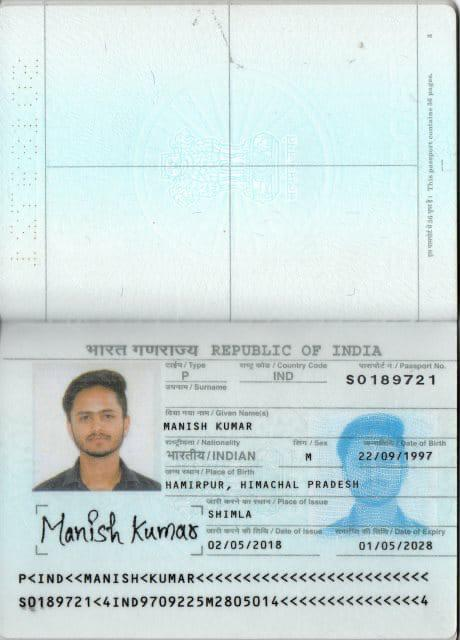

In [33]:
img = Image.open(IMG_PATH)
print("Image size:", img.size)
display(img)


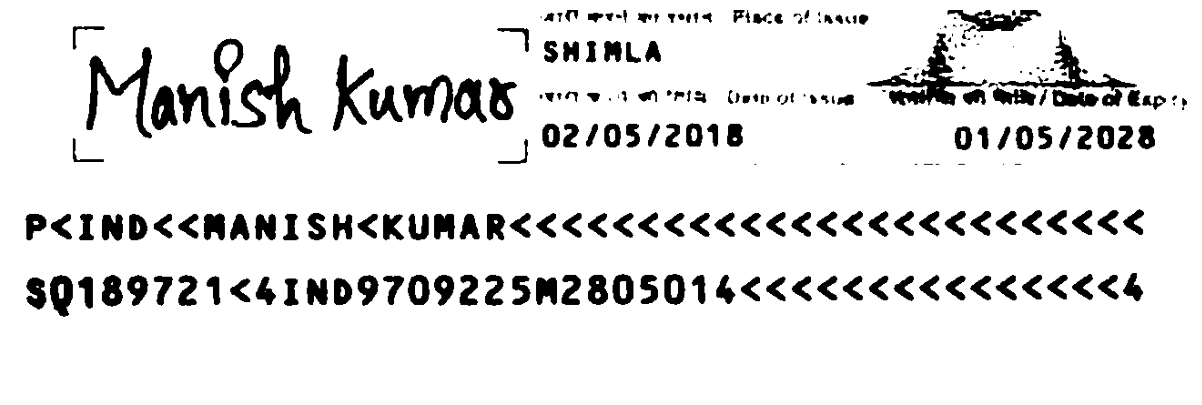

In [34]:
img_cv = cv2.imread(str(IMG_PATH))
img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]
mrz_np = img_rgb[int(h * 0.78):h, int(w * 0.03):int(w * 0.97)]

gray = cv2.cvtColor(mrz_np, cv2.COLOR_RGB2GRAY)
gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
gray = cv2.GaussianBlur(gray, (3, 3), 0)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(16, 5))
plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.show()

mrz_crop = thresh


In [35]:
def clean_mrz_text(text: str) -> list[str]:
    lines = []
    for line in text.splitlines():
        line = line.strip().upper().replace(" ", "")
        line = re.sub(r"[^A-Z0-9<]", "", line)
        if len(line) >= 20:
            lines.append(line)
    return lines

def make_preprocess_variants(gray_img):
    variants = {}
    base = cv2.resize(gray_img, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    variants["gray_up"] = base

    blur = cv2.GaussianBlur(base, (3, 3), 0)
    variants["blur"] = blur

    eq = cv2.equalizeHist(blur)
    variants["equalized"] = eq

    otsu = cv2.threshold(eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    variants["otsu"] = otsu

    inv_otsu = 255 - otsu
    variants["inv_otsu"] = inv_otsu

    adaptive = cv2.adaptiveThreshold(
        eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 15
    )
    variants["adaptive"] = adaptive

    morph = cv2.morphologyEx(otsu, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))
    variants["morph_close"] = morph
    return variants

def tesseract_read(img):
    return pytesseract.image_to_string(
        img,
        config="--oem 1 --psm 6 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789< -c load_system_dawg=0 -c load_freq_dawg=0"
    )

def easyocr_read(img):
    results = EASYOCR_READER.readtext(
        img,
        detail=1,
        paragraph=False,
        allowlist=MRZ_ALLOWLIST
    )
    return "\n".join([r[1] for r in results])

def mrz_line_score(line: str) -> int:
    line = re.sub(r"[^A-Z0-9<]", "", line.upper())
    score = 0

    if len(line) == 44:
        score += 80
    elif 40 <= len(line) <= 46:
        score += 40
    else:
        score -= abs(44 - len(line)) * 3

    score += sum(ch in MRZ_ALLOWLIST for ch in line)

    if line.startswith("P<"):
        score += 50

    if "<<" in line:
        score += 25

    if re.fullmatch(r"[A-Z0-9<]+", line):
        score += 20

    return score

def line2_field_score(line2: str) -> int:
    s = re.sub(r"[^A-Z0-9<]", "", line2.upper())[:44].ljust(44, "<")
    score = 0

    passport_no = s[0:9]
    passport_cd = s[9]
    nationality = s[10:13]
    birth = s[13:19]
    birth_cd = s[19]
    sex = s[20]
    expiry = s[21:27]
    expiry_cd = s[27]
    personal = s[28:42]
    personal_cd = s[42]
    final_cd = s[43]

    if re.fullmatch(r"[A-Z0-9<]{9}", passport_no):
        score += 20
    if passport_cd.isdigit():
        score += 15
        try:
            if mrz_checksum(passport_no) == passport_cd:
                score += 35
        except:
            pass

    if re.fullmatch(r"[A-Z<]{3}", nationality):
        score += 20
        if nationality in COMMON_NATIONALITY_CODES:
            score += 30

    if re.fullmatch(r"\d{6}", birth):
        score += 20
        if birth_cd.isdigit():
            score += 15
            try:
                if mrz_checksum(birth) == birth_cd:
                    score += 35
            except:
                pass

    if sex in {"M", "F", "<"}:
        score += 20

    if re.fullmatch(r"\d{6}", expiry):
        score += 20
        if expiry_cd.isdigit():
            score += 15
            try:
                if mrz_checksum(expiry) == expiry_cd:
                    score += 35
            except:
                pass

    if personal == "<" * 14:
        score += 25
    else:
        score += sum(ch in MRZ_ALLOWLIST for ch in personal)

    if personal_cd == "<" and personal == "<" * 14:
        score += 25
    elif personal_cd.isdigit():
        score += 10
        try:
            if mrz_checksum(personal) == personal_cd:
                score += 20
        except:
            pass

    if final_cd.isdigit():
        composite_text = s[0:10] + s[10:13] + s[13:20] + s[20] + s[21:43]
        try:
            if mrz_checksum(composite_text) == final_cd:
                score += 40
        except:
            pass

    return score

def rank_candidate_pair(lines):
    cleaned = [
        re.sub(r"[^A-Z0-9<]", "", x.upper())
        for x in lines
        if len(re.sub(r"[^A-Z0-9<]", "", x.upper())) >= 20
    ]
    if len(cleaned) < 2:
        return None

    best = None
    for i in range(len(cleaned)):
        for j in range(len(cleaned)):
            if i == j:
                continue
            l1 = cleaned[i]
            l2 = cleaned[j]

            pair_score = mrz_line_score(l1) + mrz_line_score(l2)

            if l1.startswith("P<"):
                pair_score += 60

            pair_score += line2_field_score(l2)

            if best is None or pair_score > best["score"]:
                best = {"line1": l1, "line2": l2, "score": pair_score}

    return best

gray_input = mrz_crop if len(mrz_crop.shape) == 2 else cv2.cvtColor(mrz_crop, cv2.COLOR_RGB2GRAY)
variants = make_preprocess_variants(gray_input)

all_runs = []

for variant_name, variant_img in variants.items():
    tess_text = tesseract_read(variant_img)
    tess_lines = clean_mrz_text(tess_text)
    tess_best = rank_candidate_pair(tess_lines)
    all_runs.append({
        "engine": "tesseract",
        "variant": variant_name,
        "raw_text": tess_text,
        "lines": tess_lines,
        "best": tess_best
    })

    easy_text = easyocr_read(variant_img)
    easy_lines = clean_mrz_text(easy_text)
    easy_best = rank_candidate_pair(easy_lines)
    all_runs.append({
        "engine": "easyocr",
        "variant": variant_name,
        "raw_text": easy_text,
        "lines": easy_lines,
        "best": easy_best
    })

scored_runs = []
for run in all_runs:
    if run["best"] is None:
        continue
    scored_runs.append({
        **run,
        "score": run["best"]["score"],
        "line1": run["best"]["line1"][:44].ljust(44, "<"),
        "line2": run["best"]["line2"][:44].ljust(44, "<")
    })

if not scored_runs:
    raise RuntimeError("No plausible MRZ candidate pair found")

best_run = max(scored_runs, key=lambda r: r["score"])

print("BEST OCR ENGINE:", best_run["engine"])
print("BEST PREPROCESS:", best_run["variant"])
print("BEST SCORE:", best_run["score"])
print("SELECTED CANDIDATE LINES:")
print(best_run["line1"])
print(best_run["line2"])


/Users/hrugvedambre/Documents/MRZ-passport-scan/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/hrugvedambre/Documents/MRZ-passport-scan/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/hrugvedambre/Documents/MRZ-passport-scan/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/hrugvedambre/Documents/MRZ-passport-scan/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned m

BEST OCR ENGINE: easyocr
BEST PREPROCESS: gray_up
BEST SCORE: 688
SELECTED CANDIDATE LINES:
P<INDKKNANISHKKUHAR<<<<<K<<<<K<K<<K<<<KK<KK<
8Q189721<6IND970922502805016<<<<<<<<<<<<<<<6


In [36]:
def normalize_mrz_line(line: str) -> str:
    return re.sub(r"[^A-Z0-9<]", "", line.strip().upper().replace(" ", ""))

def parse_td3(line1: str, line2: str) -> dict:
    line1 = normalize_mrz_line(line1)[:44].ljust(44, "<")
    line2 = normalize_mrz_line(line2)[:44].ljust(44, "<")

    names_raw = line1[5:44]
    name_parts = names_raw.split("<<", 1)

    surname = name_parts[0].replace("<", " ").strip()
    given_names = name_parts[1].replace("<", " ").strip() if len(name_parts) > 1 else ""

    passport_number_raw = line2[0:9]
    passport_number_cd = line2[9]
    nationality = line2[10:13]
    birth_raw = line2[13:19]
    birth_cd = line2[19]
    sex = line2[20]
    expiry_raw = line2[21:27]
    expiry_cd = line2[27]
    personal_number_raw = line2[28:42]
    personal_number_cd = line2[42]
    composite_cd = line2[43]
    composite_text = line2[0:10] + line2[13:20] + line2[21:43]

    return {
        "document_type": line1[0:2].replace("<", "").strip(),
        "issuing_country": line1[2:5],
        "surname": surname,
        "given_names": " ".join(given_names.split()),
        "passport_number": passport_number_raw.replace("<", ""),
        "nationality": nationality.replace("<", ""),
        "date_of_birth_yymmdd": birth_raw,
        "sex": sex.replace("<", ""),
        "date_of_expiry_yymmdd": expiry_raw,
        "personal_number": personal_number_raw.replace("<", ""),
        "raw_line_1": line1,
        "raw_line_2": line2,
        "valid_passport_number": is_valid_check(passport_number_raw, passport_number_cd),
        "valid_birth_date": is_valid_check(birth_raw, birth_cd),
        "valid_expiry_date": is_valid_check(expiry_raw, expiry_cd),
        "valid_personal_number": personal_number_cd == "<" or is_valid_check(personal_number_raw, personal_number_cd),
        "valid_composite": is_valid_check(composite_text, composite_cd),
    }

result = parse_td3(best_run["line1"], best_run["line2"])
result


{'document_type': 'P',
 'issuing_country': 'IND',
 'surname': 'KKNANISHKKUHAR',
 'given_names': 'K K K K KK KK',
 'passport_number': '8Q189721',
 'nationality': 'IND',
 'date_of_birth_yymmdd': '970922',
 'sex': '0',
 'date_of_expiry_yymmdd': '280501',
 'personal_number': '',
 'raw_line_1': 'P<INDKKNANISHKKUHAR<<<<<K<<<<K<K<<K<<<KK<KK<',
 'raw_line_2': '8Q189721<6IND970922502805016<<<<<<<<<<<<<<<6',
 'valid_passport_number': False,
 'valid_birth_date': True,
 'valid_expiry_date': False,
 'valid_personal_number': True,
 'valid_composite': False}